# 1.1 MACCS mechanism-aligned transfer benchmark

This notebook establishes the canonical MACCS benchmark for the controlled
Ru-AHK → Ru-AHO transfer problem.

The target domain is fixed as inner-sphere Ru-AHO. Three predictive settings
are evaluated under the same five target folds and the same 11 classical
regressors:

1. target-only Ru-AHO;
2. mechanism-aligned transfer from inner-sphere Ru-AHK;
3. mechanism-mismatched transfer from outer-sphere Ru-AHK.

For each transfer source, mixed transfer and delta learning are both evaluated.
Pooled out-of-fold R² is the primary metric; MAE and RMSE are reported as
supporting metrics.

Outputs are written to:

`results/1_1_maccs_mechanism_transfer/`


In [1]:
import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.errors import EmptyDataError

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)

SOURCE_RULE_COLORS = {
    "target_only": "#7A7A7A",
    "mechanism_aligned": "#0072B2",
    "mechanism_mismatched": "#D55E00",
    "all_ru_ahk": "#7B61A8",
    "substrate_similar": "#009E73",
    "ligand_similar": "#E69F00",
    "reaction_feature_similar": "#56B4E9",
}

from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors
from rdkit.DataStructs import ConvertToNumpyArray

try:
    from rdkit.Chem import rdFingerprintGenerator
    HAS_FINGERPRINT_GENERATOR = True
except Exception:
    rdFingerprintGenerator = None
    HAS_FINGERPRINT_GENERATOR = False

try:
    from rdkit.Avalon import pyAvalonTools
    HAS_AVALON = True
except Exception:
    pyAvalonTools = None
    HAS_AVALON = False

from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
warnings.filterwarnings("ignore", category=ConvergenceWarning)
RDLogger.DisableLog("rdApp.warning")

RANDOM_STATE = 42
N_FOLDS = 5
MACCS_LENGTH = 167
TARGET_COLUMN = "ddG"
COMPONENT_COLUMNS = [
    "Reactant SMILES",
    "Product SMILES",
    "Additive SMILES",
    "Solvent SMILES",
    "Ligand SMILES",
]
CONDITION_COLUMNS = ["Pressure/atm", "Temperature/C", "S/C"]


# Keep result-level and feature-level caches separate.
# Recompute model predictions only when intentionally requested.
FORCE_RECOMPUTE_RESULTS = False
FORCE_RECOMPUTE_FEATURES = False


def find_project_root(start=None):
    """Find the project root containing the canonical data/transfer directory."""
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "data" / "transfer").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TRANSFER_DIR = PROJECT_ROOT / "data" / "transfer"
OUT_DIR = PROJECT_ROOT / "results" / "1_1_maccs_mechanism_transfer"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
FEATURE_CACHE_DIR = OUT_DIR / "feature_cache"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

OOF_PATH = TABLE_DIR / "maccs_ru_inner_outer_to_aho_inner_oof_predictions.csv"

FEATURE_CACHE_PATH = FEATURE_CACHE_DIR / "maccs_combined_feature_matrix.npy"

# Remove legacy sidecar outputs from earlier, more verbose versions of this notebook.
OBSOLETE_OUTPUT_PATHS = [
    TABLE_DIR / "maccs_model_parameter_audit.csv",
    TABLE_DIR / "maccs_ru_domain_summary.csv",
    TABLE_DIR / "maccs_ru_inner_outer_to_aho_inner_errors.csv",
]
for obsolete_path in OBSOLETE_OUTPUT_PATHS:
    if obsolete_path.exists():
        obsolete_path.unlink()
for obsolete_path in FEATURE_CACHE_DIR.glob("*maccs*.metadata.json"):
    obsolete_path.unlink()
for obsolete_path in FEATURE_CACHE_DIR.glob("*maccs*.npy"):
    if obsolete_path != FEATURE_CACHE_PATH:
        obsolete_path.unlink()

DOMAIN_FILES = OrderedDict(
    [
        ("ru_ahk_inner", TRANSFER_DIR / "ru_ahk_inner.csv"),
        ("ru_ahk_outer", TRANSFER_DIR / "ru_ahk_outer.csv"),
        ("ru_aho_inner", TRANSFER_DIR / "ru_aho_inner.csv"),
    ]
)

TRANSFER_TASKS = [
    {
        "task_id": "ru_ahk_inner_to_ru_aho_inner",
        "source_key": "ru_ahk_inner",
        "target_key": "ru_aho_inner",
        "source_domain": "inner",
        "target_domain": "inner",
        "relation_label": "Same mechanism",
        "scene_label": "Ru-AHK inner -> Ru-AHO inner",
    },
    {
        "task_id": "ru_ahk_outer_to_ru_aho_inner",
        "source_key": "ru_ahk_outer",
        "target_key": "ru_aho_inner",
        "source_domain": "outer",
        "target_domain": "inner",
        "relation_label": "Different mechanism",
        "scene_label": "Ru-AHK outer -> Ru-AHO inner",
    },
]

OOF_COLUMNS = [
    "model",
    "task_id",
    "scene_label",
    "source_domain",
    "target_domain",
    "relation_label",
    "method_label",
    "fold_id",
    "target_index",
    "y_true",
    "y_pred",
]
ERROR_COLUMNS = ["model", "task_id", "method_label", "error"]


def read_csv_or_empty(path, columns=None):
    """Read a CSV cache safely, returning an empty table when the file has no parseable content."""
    if columns is None:
        columns = []
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame(columns=columns)
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame(columns=columns)


def csv_has_data_rows(path, required_columns=None):
    """Return True only when a cached CSV has at least one row and the expected columns."""
    if required_columns is None:
        required_columns = []
    cache = read_csv_or_empty(path, columns=required_columns)
    if len(cache) == 0:
        return False
    missing = [col for col in required_columns if col not in cache.columns]
    return len(missing) == 0


RESULT_CACHE_AVAILABLE = csv_has_data_rows(OOF_PATH, required_columns=OOF_COLUMNS)
NEED_FEATURE_MATRICES = FORCE_RECOMPUTE_RESULTS or not RESULT_CACHE_AVAILABLE

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUT_DIR}")
print(f"Result cache available: {RESULT_CACHE_AVAILABLE}")
print(f"Feature matrices required in this run: {NEED_FEATURE_MATRICES}")


Project root: /home/syz/ru-mechanism-transfer
Output directory: /home/syz/ru-mechanism-transfer/results/1_1_maccs_mechanism_transfer
Result cache available: False
Feature matrices required in this run: True


## 1. Load the three canonical Ru domains

The notebook reads only the three curated transfer-domain files. No task table is inferred from filenames and no cross-metal filtering is performed.


In [2]:
def _standardize_domain_table(df, dataset_label):
    """Return a clean table with the columns required for MACCS modeling."""
    df = df.copy()
    missing = [col for col in [TARGET_COLUMN, "Reactant SMILES", "Product SMILES"] if col not in df.columns]
    if missing:
        raise ValueError(f"{dataset_label} is missing required columns: {missing}")

    for col in COMPONENT_COLUMNS:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str).str.strip()

    for col in CONDITION_COLUMNS:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
    df = df.dropna(subset=[TARGET_COLUMN, "Reactant SMILES", "Product SMILES"]).reset_index(drop=True)
    if len(df) < 2:
        raise ValueError(f"{dataset_label} has too few valid rows after cleaning.")
    return df


def load_domain(path, dataset_label):
    if not path.exists():
        raise FileNotFoundError(f"Cannot find {dataset_label}: {path}")
    return _standardize_domain_table(pd.read_csv(path), dataset_label)


DOMAINS = OrderedDict((key, load_domain(path, key)) for key, path in DOMAIN_FILES.items())

DOMAIN_SUMMARY = pd.DataFrame(
    [
        {
            "domain_key": key,
            "path": str(DOMAIN_FILES[key].relative_to(PROJECT_ROOT)),
            "n_samples": len(df),
            "n_reactants": df["Reactant SMILES"].nunique(),
            "n_ligands": df["Ligand SMILES"].nunique() if "Ligand SMILES" in df.columns else np.nan,
            "ddG_mean": df[TARGET_COLUMN].mean(),
            "ddG_std": df[TARGET_COLUMN].std(),
        }
        for key, df in DOMAINS.items()
    ]
)
display(DOMAIN_SUMMARY)


,domain_key,path,n_samples,n_reactants,n_ligands,ddG_mean,ddG_std
0,ru_ahk_inner,data/transfer/ru_ahk_inner.csv,495,214,41,2.077446,0.959506
1,ru_ahk_outer,data/transfer/ru_ahk_outer.csv,1539,345,304,1.971399,0.865312
2,ru_aho_inner,data/transfer/ru_aho_inner.csv,98,38,22,1.910037,0.950583


## 2. Build or load cached MACCS feature matrices

Each reaction is represented by concatenated MACCS key fingerprints for the reactant, product, additive, solvent, and ligand, followed by numeric reaction-condition features. No metal descriptor is appended because the benchmark is restricted to Ru domains.

The computed MACCS matrices are cached as one combined `.npy` file under `feature_cache/`. On later runs, the notebook reloads this matrix and slices it back into the three canonical Ru domains by the current input-table row counts. If the input data are changed while keeping exactly the same row counts, set `FORCE_RECOMPUTE_FEATURES = True` once to rebuild the cache.


In [3]:
def _bitvect_to_pm1(bitvect, nbits):
    arr = np.zeros((nbits,), dtype=np.int8)
    ConvertToNumpyArray(bitvect, arr)
    return np.where(arr > 0, 1, -1).astype(np.int8)


def _empty_pm1(nbits):
    return -np.ones((nbits,), dtype=np.int8)


def build_maccs_vector(smiles):
    """Return a single-molecule MACCS key vector encoded as {-1, +1}.

    RDKit MACCS keys have 167 positions. Position 0 is retained to keep the
    standard RDKit bit-vector length and avoid hidden dimensionality changes.
    """
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) and smiles.strip() else None
    if mol is None:
        return _empty_pm1(MACCS_LENGTH)
    fp = rdMolDescriptors.GetMACCSKeysFingerprint(mol)
    return _bitvect_to_pm1(fp, MACCS_LENGTH)


def build_feature_matrix(df, cache=None):
    if cache is None:
        cache = {}
    rows = []
    for _, row in df.iterrows():
        component_vectors = []
        for col in COMPONENT_COLUMNS:
            smiles = str(row[col]) if pd.notna(row[col]) else ""
            if smiles not in cache:
                cache[smiles] = build_maccs_vector(smiles)
            component_vectors.append(cache[smiles])
        rows.append(np.concatenate(component_vectors))
    x_maccs = np.asarray(rows, dtype=np.float32)
    x_conditions = df[CONDITION_COLUMNS].astype(float).to_numpy(dtype=np.float32)
    return np.concatenate([x_maccs, x_conditions], axis=1).astype(np.float32)


def expected_feature_dim():
    return int(MACCS_LENGTH * len(COMPONENT_COLUMNS) + len(CONDITION_COLUMNS))


def domain_cache_slices():
    slices = OrderedDict()
    start = 0
    for key, df in DOMAINS.items():
        stop = start + len(df)
        slices[key] = slice(start, stop)
        start = stop
    return slices


def load_cached_feature_matrices():
    if FORCE_RECOMPUTE_FEATURES or not FEATURE_CACHE_PATH.exists():
        return None
    try:
        matrix = np.load(FEATURE_CACHE_PATH)
        expected_shape = (sum(len(df) for df in DOMAINS.values()), expected_feature_dim())
        if matrix.shape != expected_shape:
            print(f"Cached MACCS matrix has shape {matrix.shape}, expected {expected_shape}; rebuilding.")
            return None
        matrix = matrix.astype(np.float32, copy=False)
        slices = domain_cache_slices()
        features = OrderedDict((key, matrix[slices[key]]) for key in DOMAINS.keys())
        print(f"Loaded cached combined MACCS feature matrix: {matrix.shape}")
        return features
    except Exception as exc:
        print(f"Could not load cached MACCS feature matrix: {exc!r}; rebuilding.")
        return None


def save_cached_feature_matrices(features):
    matrix = np.vstack([features[key] for key in DOMAINS.keys()]).astype(np.float32, copy=False)
    np.save(FEATURE_CACHE_PATH, matrix)
    print(f"Saved combined MACCS feature cache: {FEATURE_CACHE_PATH} ({matrix.shape})")


FEATURE_CACHE = {}
FEATURES = OrderedDict()
TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())

if NEED_FEATURE_MATRICES:
    cached_features = load_cached_feature_matrices()
    if cached_features is not None:
        FEATURES = cached_features
    else:
        for key, df in DOMAINS.items():
            print(f"Building MACCS features for {key}: {len(df)} rows")
            FEATURES[key] = build_feature_matrix(df, cache=FEATURE_CACHE)
            print(f"  feature shape = {FEATURES[key].shape}")
        save_cached_feature_matrices(FEATURES)
else:
    print("OOF predictions are already cached. Feature matrices are not loaded in this run.")


Building MACCS features for ru_ahk_inner: 495 rows
  feature shape = (495, 838)
Building MACCS features for ru_ahk_outer: 1539 rows
  feature shape = (1539, 838)
Building MACCS features for ru_aho_inner: 98 rows
  feature shape = (98, 838)
Saved combined MACCS feature cache: /home/syz/ru-mechanism-transfer/results/1_1_maccs_mechanism_transfer/feature_cache/maccs_combined_feature_matrix.npy ((2132, 838))


## 3. Selected classical model set

The model set is explicitly defined below. 

In [4]:
MACCS_MODEL_FACTORIES = OrderedDict(
    [
        # ("AdaBoostRegressor", lambda: AdaBoostRegressor(random_state=RANDOM_STATE)),
        ("ExtraTreesRegressor", lambda: ExtraTreesRegressor(n_jobs=-1, random_state=RANDOM_STATE)),
        ("GradientBoostingRegressor", lambda: GradientBoostingRegressor(random_state=RANDOM_STATE)),
        ("HistGradientBoostingRegressor", lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
        ("RandomForestRegressor", lambda: RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE)),
        (
            "GaussianProcessRegressor",
            lambda: make_pipeline(
                StandardScaler(),
                GaussianProcessRegressor(normalize_y=True, alpha=1e-6, random_state=RANDOM_STATE),
            ),
        ),
        ("KNeighborsRegressor", lambda: make_pipeline(StandardScaler(), KNeighborsRegressor())),
        ("SVR", lambda: make_pipeline(StandardScaler(), SVR())),
        (
            "LinearSVR",
            lambda: make_pipeline(
                StandardScaler(),
                LinearSVR(random_state=RANDOM_STATE, max_iter=5000),
            ),
        ),
        ("DecisionTreeRegressor", lambda: DecisionTreeRegressor(random_state=RANDOM_STATE)),
        ("ExtraTreeRegressor", lambda: ExtraTreeRegressor(random_state=RANDOM_STATE)),
    ]
)


MODEL_KEYS_TO_RUN = list(MACCS_MODEL_FACTORIES.keys())

MODEL_AUDIT_DF = pd.DataFrame(
    [
        {
            "model": model_key,
            "factory_repr": repr(MACCS_MODEL_FACTORIES[model_key]()),
        }
        for model_key in MODEL_KEYS_TO_RUN
    ]
)
display(MODEL_AUDIT_DF)


,model,factory_repr
0,ExtraTreesRegressor,"ExtraTreesRegressor(n_jobs=-1, random_state=42)"
1,GradientBoostingRegressor,GradientBoostingRegressor(random_state=42)
2,HistGradientBoostingRegressor,HistGradientBoostingRegressor(random_state=42)
3,RandomForestRegressor,"RandomForestRegressor(n_jobs=-1, random_state=42)"
4,GaussianProcessRegressor,"Pipeline(steps=[('standardscaler', StandardSca..."
5,KNeighborsRegressor,"Pipeline(steps=[('standardscaler', StandardSca..."
6,SVR,"Pipeline(steps=[('standardscaler', StandardSca..."
7,LinearSVR,"Pipeline(steps=[('standardscaler', StandardSca..."
8,DecisionTreeRegressor,DecisionTreeRegressor(random_state=42)
9,ExtraTreeRegressor,ExtraTreeRegressor(random_state=42)


## 4. Run pooled out-of-fold transfer benchmarks

The target domain is always Ru-AHO inner. Two source-to-target tasks are evaluated:

1. Ru-AHK inner -> Ru-AHO inner, representing same-mechanism transfer.
2. Ru-AHK outer -> Ru-AHO inner, representing different-mechanism transfer.

For classical MACCS models, the transfer strategies are direct source-target mixing and source-prior delta learning. The target-only baseline is computed once for the Ru-AHO target domain.

If a valid OOF prediction table already exists, it is loaded directly. Empty error logs are handled safely and do not trigger `EmptyDataError`.


In [5]:
def make_model(model_key):
    return MACCS_MODEL_FACTORIES[model_key]()


def predict_1d(model, x):
    pred = np.asarray(model.predict(x)).reshape(-1)
    return pred.astype(float)


def kfold_splitter(y_target):
    n_splits = min(int(N_FOLDS), int(len(y_target)))
    if n_splits < 2:
        raise ValueError("The Ru-AHO target domain has too few samples for OOF evaluation.")
    return KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


def run_target_only_oof(model_key, x_target, y_target):
    rows = []
    cv = kfold_splitter(y_target)
    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        model = make_model(model_key)
        model.fit(x_target[train_idx], y_target[train_idx])
        pred = predict_1d(model, x_target[test_idx])
        for local_idx, truth, pred_value in zip(test_idx, y_target[test_idx], pred):
            rows.append(
                {
                    "model": model_key,
                    "task_id": "target_only_ru_aho_inner",
                    "scene_label": "Ru-AHO inner target-only",
                    "source_domain": "none",
                    "target_domain": "inner",
                    "relation_label": "Target-only",
                    "method_label": "Target-only",
                    "fold_id": int(fold_id),
                    "target_index": int(local_idx),
                    "y_true": float(truth),
                    "y_pred": float(pred_value),
                }
            )
    return rows


def run_transfer_oof(model_key, task, x_source, y_source, x_target, y_target):
    rows = []
    cv = kfold_splitter(y_target)

    source_prior_model = make_model(model_key)
    source_prior_model.fit(x_source, y_source)

    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]

        mixed_model = make_model(model_key)
        x_mixed = np.vstack([x_source, x_train])
        y_mixed = np.concatenate([y_source, y_train])
        mixed_model.fit(x_mixed, y_mixed)
        pred_mixed = predict_1d(mixed_model, x_test)

        delta_model = make_model(model_key)
        source_prior_train = predict_1d(source_prior_model, x_train)
        delta_model.fit(x_train, y_train - source_prior_train)
        pred_delta = predict_1d(source_prior_model, x_test) + predict_1d(delta_model, x_test)

        prediction_map = OrderedDict(
            [
                ("Mixed transfer", pred_mixed),
                ("Delta learning", pred_delta),
            ]
        )

        for method_label, pred in prediction_map.items():
            for local_idx, truth, pred_value in zip(test_idx, y_test, pred):
                rows.append(
                    {
                        "model": model_key,
                        "task_id": task["task_id"],
                        "scene_label": task["scene_label"],
                        "source_domain": task["source_domain"],
                        "target_domain": task["target_domain"],
                        "relation_label": task["relation_label"],
                        "method_label": method_label,
                        "fold_id": int(fold_id),
                        "target_index": int(local_idx),
                        "y_true": float(truth),
                        "y_pred": float(pred_value),
                    }
                )
    return rows


RUN_MODELS = FORCE_RECOMPUTE_RESULTS or not RESULT_CACHE_AVAILABLE

if not RUN_MODELS:
    MULTI_MODEL_OOF_DF = read_csv_or_empty(OOF_PATH, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(columns=ERROR_COLUMNS)
    print(f"Loaded cached OOF predictions from {OOF_PATH}")
else:
    if not FEATURES:
        raise RuntimeError(
            "Feature matrices are required for recomputation but were not built. "
            "Set FORCE_RECOMPUTE_RESULTS=False to use cached predictions, or rerun the feature-cache cell."
        )

    all_rows = []
    error_rows = []
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]

    for model_key in MODEL_KEYS_TO_RUN:
        print(f"Running {model_key}")
        try:
            all_rows.extend(run_target_only_oof(model_key, x_target, y_target))
        except Exception as exc:
            error_rows.append(
                {
                    "model": model_key,
                    "task_id": "target_only_ru_aho_inner",
                    "method_label": "Target-only",
                    "error": repr(exc),
                }
            )
            print(f"  Target-only failed for {model_key}: {exc!r}")

        for task in TRANSFER_TASKS:
            try:
                source_key = task["source_key"]
                all_rows.extend(
                    run_transfer_oof(
                        model_key,
                        task,
                        FEATURES[source_key],
                        TARGETS[source_key],
                        x_target,
                        y_target,
                    )
                )
            except Exception as exc:
                error_rows.append(
                    {
                        "model": model_key,
                        "task_id": task["task_id"],
                        "method_label": "transfer",
                        "error": repr(exc),
                    }
                )
                print(f"  Transfer failed for {model_key}, {task['task_id']}: {exc!r}")

    MULTI_MODEL_OOF_DF = pd.DataFrame(all_rows, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(error_rows, columns=ERROR_COLUMNS)
    MULTI_MODEL_OOF_DF.to_csv(OOF_PATH, index=False)

print(f"OOF prediction rows: {len(MULTI_MODEL_OOF_DF)}")
if len(ERROR_DF):
    print("Some model-task combinations failed. Inspect the error table before using the results.")
    display(ERROR_DF)


Running ExtraTreesRegressor
Running GradientBoostingRegressor
Running HistGradientBoostingRegressor
Running RandomForestRegressor
Running GaussianProcessRegressor
Running KNeighborsRegressor
Running SVR
Running LinearSVR
Running DecisionTreeRegressor
Running ExtraTreeRegressor
OOF prediction rows: 4900


## 5. Summarize metrics and generate publication-facing figures

Pooled OOF metrics are computed after concatenating predictions from all target folds. The figures are designed to directly support the manuscript comparison between same-mechanism and different-mechanism Ru transfer.


,model,task_id,scene_label,source_domain,target_domain,relation_label,method_label,R2,MAE,RMSE,n_test_total
11,ExtraTreesRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.640186,0.350487,0.567286,98
26,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.632018,0.413710,0.573688,98
0,DecisionTreeRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.619220,0.389602,0.583579,98
41,RandomForestRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.614792,0.419967,0.586963,98
25,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.604966,0.434337,0.594402,98
21,GradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.589636,0.428907,0.605825,98
48,SVR,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.562458,0.417367,0.625565,98
40,RandomForestRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.558550,0.433089,0.628353,98
20,GradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.539430,0.424694,0.641816,98
43,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.538061,0.455676,0.642769,98


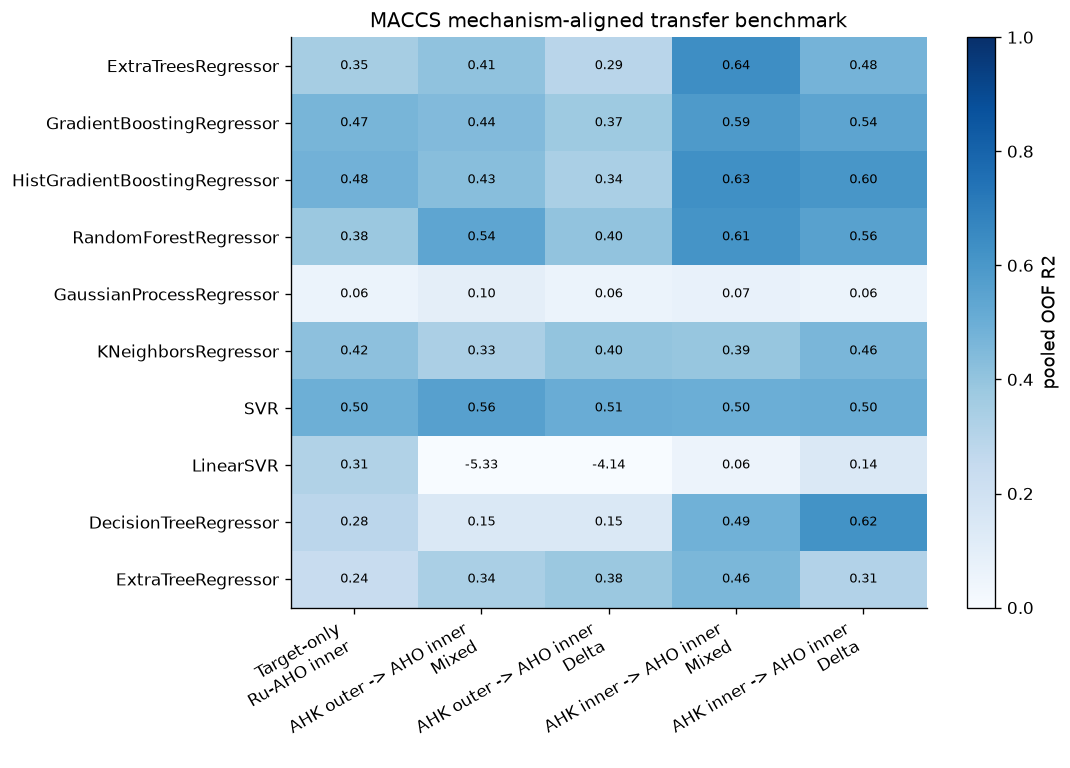

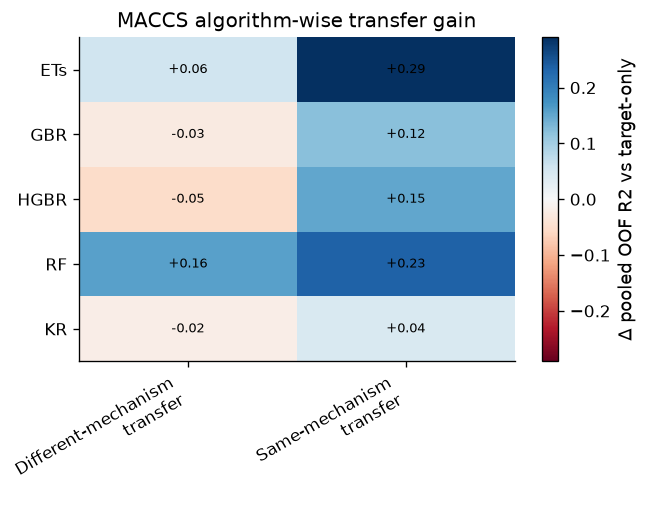

In [6]:
def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite]
    y_pred = y_pred[finite]
    return {
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan,
        "MAE": float(mean_absolute_error(y_true, y_pred)) if len(y_true) else np.nan,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))) if len(y_true) else np.nan,
        "n_test_total": int(len(y_true)),
    }


GROUP_COLUMNS = [
    "model",
    "task_id",
    "scene_label",
    "source_domain",
    "target_domain",
    "relation_label",
    "method_label",
]

metric_rows = []
for keys, group in MULTI_MODEL_OOF_DF.groupby(GROUP_COLUMNS, dropna=False):
    row = dict(zip(GROUP_COLUMNS, keys))
    row.update(pooled_metrics(group["y_true"].to_numpy(), group["y_pred"].to_numpy()))
    metric_rows.append(row)

MULTI_MODEL_SCORE_LONG = pd.DataFrame(metric_rows)
MULTI_MODEL_SCORE_LONG.to_csv(TABLE_DIR / "maccs_pooled_oof_metrics_long.csv", index=False)
display(MULTI_MODEL_SCORE_LONG.sort_values("R2", ascending=False))


def plot_column_label(row):
    if row["method_label"] == "Target-only":
        return "Target-only\nRu-AHO inner"
    method_short = {"Mixed transfer": "Mixed", "Delta learning": "Delta"}.get(row["method_label"], row["method_label"])
    source_short = "AHK inner" if row["source_domain"] == "inner" else "AHK outer"
    return f"{source_short} -> AHO inner\n{method_short}"


plot_score = MULTI_MODEL_SCORE_LONG.copy()
plot_score["plot_col"] = plot_score.apply(plot_column_label, axis=1)
HEATMAP_COLUMN_ORDER = [
    "Target-only\nRu-AHO inner",
    "AHK outer -> AHO inner\nMixed",
    "AHK outer -> AHO inner\nDelta",
    "AHK inner -> AHO inner\nMixed",
    "AHK inner -> AHO inner\nDelta",
]

R2_HEATMAP = (
    plot_score.pivot_table(index="model", columns="plot_col", values="R2", aggfunc="mean")
    .reindex(index=MODEL_KEYS_TO_RUN)
    .reindex(columns=[col for col in HEATMAP_COLUMN_ORDER if col in plot_score["plot_col"].unique()])
)
R2_HEATMAP.to_csv(TABLE_DIR / "maccs_pooled_oof_r2_heatmap_table.csv")


def plot_annotated_heatmap(table, out_path, title, cbar_label="pooled OOF R2"):
    values = table.to_numpy(dtype=float)
    color_values = np.clip(values, 0.0, 1.0)
    masked_values = np.ma.masked_invalid(color_values)

    fig_w = max(7.2, 1.45 * table.shape[1] + 2.0)
    fig_h = max(4.2, 0.48 * table.shape[0] + 1.7)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(masked_values, aspect="auto", cmap="Blues", vmin=0.0, vmax=1.0)

    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels(table.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_title(title)

    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{float(value):.2f}", ha="center", va="center", fontsize=8, color="black")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()


plot_annotated_heatmap(
    R2_HEATMAP,
    FIG_DIR / "maccs_selected_models_pooled_oof_R2_heatmap_0_1.svg",
    "MACCS mechanism-aligned transfer benchmark",
    "pooled OOF R2",
)


COMPACT_HEATMAP_MODELS = OrderedDict(
    [
        ("ExtraTreesRegressor", "ETs"),
        ("GradientBoostingRegressor", "GBR"),
        ("HistGradientBoostingRegressor", "HGBR"),
        ("RandomForestRegressor", "RF"),
        ("KNeighborsRegressor", "KR"),
    ]
)


def best_transfer_r2(score_long, model_key, relation_label):
    sub = score_long.loc[
        score_long["model"].eq(model_key)
        & score_long["relation_label"].eq(relation_label)
        & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
    ].copy()
    if len(sub) == 0:
        return np.nan
    return float(sub["R2"].max())


transfer_gain_rows = []
for model_key, short_label in COMPACT_HEATMAP_MODELS.items():
    baseline_sub = MULTI_MODEL_SCORE_LONG.loc[
        MULTI_MODEL_SCORE_LONG["model"].eq(model_key)
        & MULTI_MODEL_SCORE_LONG["method_label"].eq("Target-only")
    ].copy()
    baseline_r2 = float(baseline_sub["R2"].iloc[0]) if len(baseline_sub) else np.nan
    different_r2 = best_transfer_r2(MULTI_MODEL_SCORE_LONG, model_key, "Different mechanism")
    same_r2 = best_transfer_r2(MULTI_MODEL_SCORE_LONG, model_key, "Same mechanism")

    transfer_gain_rows.append(
        {
            "model": short_label,
            "Different-mechanism\ntransfer": different_r2 - baseline_r2 if pd.notna(different_r2) and pd.notna(baseline_r2) else np.nan,
            "Same-mechanism\ntransfer": same_r2 - baseline_r2 if pd.notna(same_r2) and pd.notna(baseline_r2) else np.nan,
        }
    )

TRANSFER_GAIN_HEATMAP = pd.DataFrame(transfer_gain_rows).set_index("model")
TRANSFER_GAIN_HEATMAP.to_csv(
    TABLE_DIR / "maccs_selected_models_transfer_gain_heatmap_table.csv"
)


def plot_transfer_gain_heatmap(table, out_path, title):
    values = table.to_numpy(dtype=float)
    masked_values = np.ma.masked_invalid(values)
    finite = values[np.isfinite(values)]
    max_abs = float(np.max(np.abs(finite))) if finite.size else 0.1
    max_abs = max(max_abs, 0.05)

    fig_w = max(5.4, 1.9 * table.shape[1] + 1.8)
    fig_h = max(4.0, 0.55 * table.shape[0] + 1.6)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(masked_values, aspect="auto", cmap="RdBu", vmin=-max_abs, vmax=max_abs)

    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels(table.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_title(title)

    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{float(value):+.2f}", ha="center", va="center", fontsize=8, color="black")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Δ pooled OOF R2 vs target-only")
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()


plot_transfer_gain_heatmap(
    TRANSFER_GAIN_HEATMAP,
    FIG_DIR / "maccs_selected_models_transfer_gain_heatmap.svg",
    "MACCS algorithm-wise transfer gain",
)


,descriptor,model,task_id,scene_label,source_domain,target_domain,relation_label,method_label,R2,MAE,RMSE,n_test_total,display_name,selection,point_color
0,MACCS,SVR,target_only_ru_aho_inner,Ru-AHO inner target-only,none,inner,Target-only,Target-only,0.495043,0.452117,0.672032,98,Best target-only baseline,baseline,#009E73
1,MACCS,SVR,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.562458,0.417367,0.625565,98,Best different-mechanism transfer,different_mechanism_transfer,#D55E00
2,MACCS,ExtraTreesRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.640186,0.350487,0.567286,98,Best same-mechanism transfer,same_mechanism_transfer,#0072B2


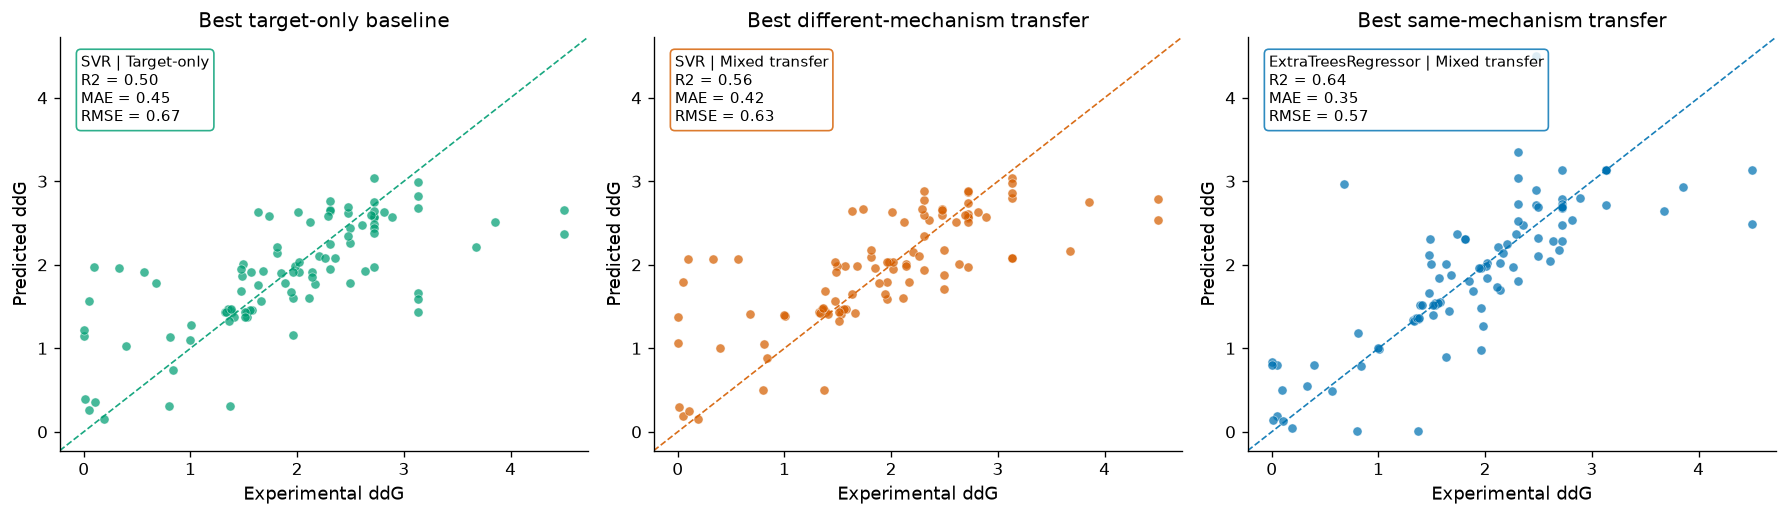

In [7]:
def select_best_score_row(score_long, selection):
    if selection == "baseline":
        sub = score_long.loc[score_long["method_label"].eq("Target-only")].copy()
    elif selection == "same_mechanism_transfer":
        sub = score_long.loc[
            score_long["relation_label"].eq("Same mechanism")
            & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
        ].copy()
    elif selection == "different_mechanism_transfer":
        sub = score_long.loc[
            score_long["relation_label"].eq("Different mechanism")
            & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
        ].copy()
    else:
        raise ValueError(selection)
    if len(sub) == 0:
        raise ValueError(f"No rows found for selection={selection!r}")
    return sub.sort_values("R2", ascending=False).iloc[0]


PARITY_SELECTION_STYLES = OrderedDict(
    [
        (
            "baseline",
            {
                "display_name": "Best target-only baseline",
                "point_color": "#009E73",
            },
        ),
        (
            "different_mechanism_transfer",
            {
                "display_name": "Best different-mechanism transfer",
                "point_color": "#D55E00",
            },
        ),
        (
            "same_mechanism_transfer",
            {
                "display_name": "Best same-mechanism transfer",
                "point_color": "#0072B2",
            },
        ),
    ]
)


SELECTED_ROWS = []
for selection, style in PARITY_SELECTION_STYLES.items():
    row = select_best_score_row(MULTI_MODEL_SCORE_LONG, selection)
    item = row.to_dict()
    item["display_name"] = style["display_name"]
    item["selection"] = selection
    item["point_color"] = style["point_color"]
    SELECTED_ROWS.append(item)

SELECTED_OUTCOME_DF = pd.DataFrame(SELECTED_ROWS)
SELECTED_OUTCOME_DF.insert(0, "descriptor", "MACCS")
SELECTED_OUTCOME_DF.to_csv(TABLE_DIR / "maccs_selected_best_outcomes_for_parity.csv", index=False)
display(SELECTED_OUTCOME_DF)


def get_oof_predictions_for_selected(row):
    mask = (
        MULTI_MODEL_OOF_DF["model"].eq(row["model"])
        & MULTI_MODEL_OOF_DF["task_id"].eq(row["task_id"])
        & MULTI_MODEL_OOF_DF["method_label"].eq(row["method_label"])
    )
    pred = MULTI_MODEL_OOF_DF.loc[mask].copy()
    if len(pred) == 0:
        raise ValueError(f"Cannot find OOF predictions for selected outcome: {row.to_dict()}")
    return pred


def metrics_from_prediction_df(pred):
    return pooled_metrics(pred["y_true"].to_numpy(), pred["y_pred"].to_numpy())


def plot_parity_panel(ax, pred, title, subtitle, point_color):
    y_true = pred["y_true"].to_numpy(dtype=float)
    y_pred = pred["y_pred"].to_numpy(dtype=float)
    metric = metrics_from_prediction_df(pred)

    ax.scatter(y_true, y_pred, s=30, alpha=0.72, color=point_color, edgecolors="white", linewidths=0.35)
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    if finite.any():
        lo = float(np.nanmin([y_true[finite].min(), y_pred[finite].min()]))
        hi = float(np.nanmax([y_true[finite].max(), y_pred[finite].max()]))
        pad = 0.05 * (hi - lo) if hi > lo else 0.5
        lo -= pad
        hi += pad
        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.0, color=point_color, alpha=0.9)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

    ax.set_xlabel("Experimental ddG")
    ax.set_ylabel("Predicted ddG")
    ax.set_title(title)
    ax.text(
        0.04,
        0.96,
        subtitle + f"\nR2 = {metric['R2']:.2f}\nMAE = {metric['MAE']:.2f}\nRMSE = {metric['RMSE']:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.82, "edgecolor": point_color},
    )


fig, axes = plt.subplots(1, len(SELECTED_OUTCOME_DF), figsize=(5.0 * len(SELECTED_OUTCOME_DF), 4.4))
if len(SELECTED_OUTCOME_DF) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, SELECTED_OUTCOME_DF.iterrows()):
    pred = get_oof_predictions_for_selected(row)
    subtitle = f"{row['model']} | {row['method_label']}"
    plot_parity_panel(ax, pred, row["display_name"], subtitle, row["point_color"])

fig.tight_layout()
fig.savefig(FIG_DIR / "maccs_selected_best_parity_plots.svg", bbox_inches="tight")
plt.show()


## 6. Seed-landscape diagnostic across target split seeds

To avoid making the validation depend on a hand-picked meta-seed protocol, this section exhaustively scans target-domain 5-fold split seeds from 0 to 100. The model and transfer method selected above are kept fixed, and the diagnostic reports how much the same-mechanism transfer setting outperforms the different-mechanism transfer setting under each split.



Feature matrices available for seed-landscape diagnostic: {'ru_ahk_inner': (495, 838), 'ru_ahk_outer': (1539, 838), 'ru_aho_inner': (98, 838)}
Same-mechanism setting: same_mechanism_transfer|ExtraTreesRegressor|ru_ahk_inner_to_ru_aho_inner|Mixed transfer
Different-mechanism setting: different_mechanism_transfer|SVR|ru_ahk_outer_to_ru_aho_inner|Mixed transfer
Seed-landscape diagnostic: split_seed=0
Seed-landscape diagnostic: split_seed=1
Seed-landscape diagnostic: split_seed=2
Seed-landscape diagnostic: split_seed=3
Seed-landscape diagnostic: split_seed=4
Seed-landscape diagnostic: split_seed=5
Seed-landscape diagnostic: split_seed=6
Seed-landscape diagnostic: split_seed=7
Seed-landscape diagnostic: split_seed=8
Seed-landscape diagnostic: split_seed=9
Seed-landscape diagnostic: split_seed=10
Seed-landscape diagnostic: split_seed=11
Seed-landscape diagnostic: split_seed=12
Seed-landscape diagnostic: split_seed=13
Seed-landscape diagnostic: split_seed=14
Seed-landscape diagnostic: split_s

,split_seed,same_model,same_method_label,different_model,different_method_label,same_mechanism_R2,different_mechanism_R2,delta_R2_same_minus_different
42,42,ExtraTreesRegressor,Mixed transfer,SVR,Mixed transfer,0.640186,0.562458,0.077728


Saved necessary Section 6 metrics table to: /home/syz/ru-mechanism-transfer/results/1_1_maccs_mechanism_transfer/tables/maccs_seed_landscape_metrics.csv


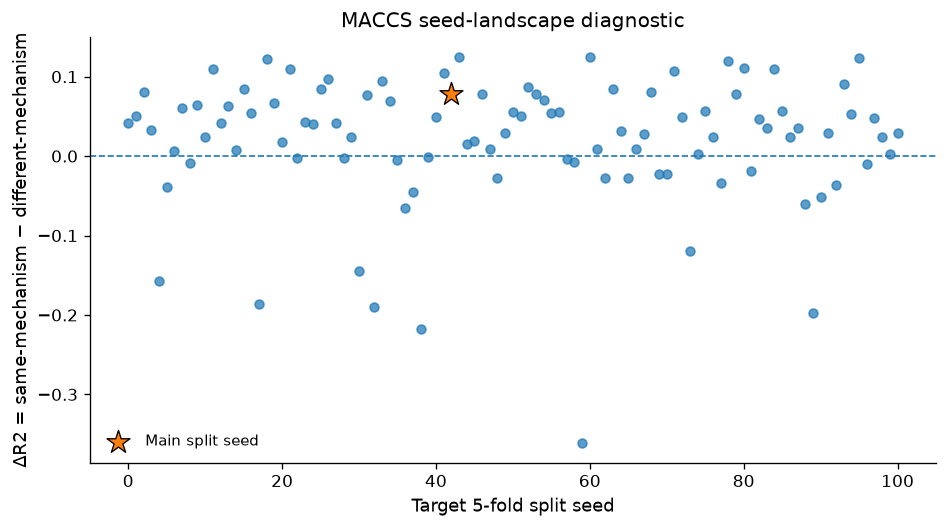

Saved Section 6 diagnostic figure to: /home/syz/ru-mechanism-transfer/results/1_1_maccs_mechanism_transfer/figures/maccs_seed_landscape_diagnostic.svg


In [8]:
SEED_LANDSCAPE_MIN_SEED = 0
SEED_LANDSCAPE_MAX_SEED = 100
SEED_LANDSCAPE_SPLIT_SEEDS = list(range(SEED_LANDSCAPE_MIN_SEED, SEED_LANDSCAPE_MAX_SEED + 1))
FORCE_RECOMPUTE_SEED_LANDSCAPE = False

SEED_LANDSCAPE_METRICS_TABLE = TABLE_DIR / "maccs_seed_landscape_metrics.csv"
SEED_LANDSCAPE_FIG = FIG_DIR / "maccs_seed_landscape_diagnostic.svg"

# Remove verbose outputs from the earlier meta-seed validation version.
OBSOLETE_SECTION6_OUTPUTS = [
    TABLE_DIR / "maccs_meta_seed_generated_split_seeds.csv",
    TABLE_DIR / "maccs_meta_seed_split_validation_metrics.csv",
    TABLE_DIR / "maccs_meta_seed_split_validation_predictions.csv",
    FIG_DIR / "maccs_meta_seed_split_validation_boxplot.svg",
]
for obsolete_path in OBSOLETE_SECTION6_OUTPUTS:
    if obsolete_path.exists():
        obsolete_path.unlink()


# Make feature matrices available for the seed-landscape section.
# If the main OOF table was loaded from cache, earlier cells may have skipped feature loading.
def ensure_maccs_features_available():
    global FEATURES, FEATURE_CACHE, TARGETS

    required_keys = list(DOMAINS.keys())
    existing_features = globals().get("FEATURES", OrderedDict())
    if isinstance(existing_features, OrderedDict) and all(key in existing_features for key in required_keys):
        FEATURES = existing_features
        TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())
        return

    cached_features = load_cached_feature_matrices()
    if cached_features is not None:
        FEATURES = cached_features
    else:
        print("MACCS feature cache is missing or incompatible; rebuilding features for seed-landscape diagnostic.")
        FEATURE_CACHE = {}
        FEATURES = OrderedDict()
        for key, df in DOMAINS.items():
            print(f"Building MACCS features for {key}: {len(df)} rows")
            FEATURES[key] = build_feature_matrix(df, cache=FEATURE_CACHE)
        save_cached_feature_matrices(FEATURES)

    TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())


def get_transfer_task_by_id(task_id):
    for task in TRANSFER_TASKS:
        if task["task_id"] == task_id:
            return task
    raise ValueError(f"Unknown transfer task_id: {task_id!r}")


def kfold_splitter_for_seed(y_target, split_seed):
    n_splits = min(int(N_FOLDS), int(len(y_target)))
    if n_splits < 2:
        raise ValueError("The Ru-AHO target domain has too few samples for OOF evaluation.")
    return KFold(n_splits=n_splits, shuffle=True, random_state=int(split_seed))


def run_selected_transfer_outcome_for_seed(selected_row, split_seed):
    """Run one fixed selected transfer outcome under a target-domain split seed."""
    model_key = selected_row["model"]
    method_label = selected_row["method_label"]
    task = get_transfer_task_by_id(selected_row["task_id"])

    x_source = FEATURES[task["source_key"]]
    y_source = TARGETS[task["source_key"]]
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]
    cv = kfold_splitter_for_seed(y_target, split_seed)

    source_prior_model = make_model(model_key)
    source_prior_model.fit(x_source, y_source)

    rows = []
    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]

        if method_label == "Mixed transfer":
            model = make_model(model_key)
            model.fit(np.vstack([x_source, x_train]), np.concatenate([y_source, y_train]))
            pred = predict_1d(model, x_test)
        elif method_label == "Delta learning":
            delta_model = make_model(model_key)
            source_prior_train = predict_1d(source_prior_model, x_train)
            delta_model.fit(x_train, y_train - source_prior_train)
            pred = predict_1d(source_prior_model, x_test) + predict_1d(delta_model, x_test)
        else:
            raise ValueError(f"This seed-landscape diagnostic expects a transfer method, got {method_label!r}")

        for local_idx, truth, pred_value in zip(test_idx, y_test, pred):
            rows.append(
                {
                    "split_seed": int(split_seed),
                    "selection": selected_row["selection"],
                    "model": model_key,
                    "task_id": selected_row["task_id"],
                    "relation_label": selected_row["relation_label"],
                    "method_label": method_label,
                    "fold_id": int(fold_id),
                    "target_index": int(local_idx),
                    "y_true": float(truth),
                    "y_pred": float(pred_value),
                }
            )
    return pd.DataFrame(rows)


def selected_transfer_row(selection):
    sub = SELECTED_OUTCOME_DF.loc[SELECTED_OUTCOME_DF["selection"].eq(selection)].copy()
    if len(sub) != 1:
        raise ValueError(f"Expected exactly one selected row for {selection!r}, found {len(sub)}")
    row = sub.iloc[0]
    if row["method_label"] == "Target-only":
        raise ValueError(f"Seed-landscape diagnostic requires transfer rows, got target-only for {selection!r}")
    return row


SAME_SELECTED_ROW = selected_transfer_row("same_mechanism_transfer")
DIFF_SELECTED_ROW = selected_transfer_row("different_mechanism_transfer")


def selected_signature(row):
    return "|".join(
        [
            str(row["selection"]),
            str(row["model"]),
            str(row["task_id"]),
            str(row["method_label"]),
        ]
    )


EXPECTED_SAME_SIGNATURE = selected_signature(SAME_SELECTED_ROW)
EXPECTED_DIFF_SIGNATURE = selected_signature(DIFF_SELECTED_ROW)


def seed_landscape_cache_is_compatible(path):
    if FORCE_RECOMPUTE_SEED_LANDSCAPE or not path.exists():
        return False
    try:
        cached = pd.read_csv(path)
    except (EmptyDataError, pd.errors.ParserError):
        return False

    required = {
        "split_seed",
        "same_mechanism_R2",
        "different_mechanism_R2",
        "delta_R2_same_minus_different",
        "same_signature",
        "different_signature",
    }
    if not required.issubset(cached.columns):
        return False

    observed_seeds = set(cached["split_seed"].astype(int).unique())
    expected_seeds = set(SEED_LANDSCAPE_SPLIT_SEEDS)
    if observed_seeds != expected_seeds:
        return False

    return (
        set(cached["same_signature"].astype(str).unique()) == {EXPECTED_SAME_SIGNATURE}
        and set(cached["different_signature"].astype(str).unique()) == {EXPECTED_DIFF_SIGNATURE}
    )


ensure_maccs_features_available()
print("Feature matrices available for seed-landscape diagnostic:", {key: FEATURES[key].shape for key in FEATURES})
print("Same-mechanism setting:", EXPECTED_SAME_SIGNATURE)
print("Different-mechanism setting:", EXPECTED_DIFF_SIGNATURE)

if seed_landscape_cache_is_compatible(SEED_LANDSCAPE_METRICS_TABLE):
    SEED_LANDSCAPE_METRICS = pd.read_csv(SEED_LANDSCAPE_METRICS_TABLE)
    print(f"Loaded cached seed-landscape metrics from {SEED_LANDSCAPE_METRICS_TABLE}")
else:
    metric_rows = []
    for split_seed in SEED_LANDSCAPE_SPLIT_SEEDS:
        print(f"Seed-landscape diagnostic: split_seed={split_seed}")

        same_pred = run_selected_transfer_outcome_for_seed(SAME_SELECTED_ROW, split_seed)
        diff_pred = run_selected_transfer_outcome_for_seed(DIFF_SELECTED_ROW, split_seed)
        same_metrics = pooled_metrics(same_pred["y_true"].to_numpy(), same_pred["y_pred"].to_numpy())
        diff_metrics = pooled_metrics(diff_pred["y_true"].to_numpy(), diff_pred["y_pred"].to_numpy())

        metric_rows.append(
            {
                "descriptor": "MACCS",
                "split_seed": int(split_seed),
                "same_signature": EXPECTED_SAME_SIGNATURE,
                "different_signature": EXPECTED_DIFF_SIGNATURE,
                "same_model": SAME_SELECTED_ROW["model"],
                "same_task_id": SAME_SELECTED_ROW["task_id"],
                "same_method_label": SAME_SELECTED_ROW["method_label"],
                "different_model": DIFF_SELECTED_ROW["model"],
                "different_task_id": DIFF_SELECTED_ROW["task_id"],
                "different_method_label": DIFF_SELECTED_ROW["method_label"],
                "same_mechanism_R2": same_metrics["R2"],
                "different_mechanism_R2": diff_metrics["R2"],
                "delta_R2_same_minus_different": same_metrics["R2"] - diff_metrics["R2"],
                "same_mechanism_MAE": same_metrics["MAE"],
                "different_mechanism_MAE": diff_metrics["MAE"],
                "same_mechanism_RMSE": same_metrics["RMSE"],
                "different_mechanism_RMSE": diff_metrics["RMSE"],
                "n_test_total": same_metrics["n_test_total"],
            }
        )

    SEED_LANDSCAPE_METRICS = pd.DataFrame(metric_rows).sort_values("split_seed").reset_index(drop=True)
    SEED_LANDSCAPE_METRICS.to_csv(SEED_LANDSCAPE_METRICS_TABLE, index=False)

SEED_LANDSCAPE_METRICS = SEED_LANDSCAPE_METRICS.sort_values("split_seed").reset_index(drop=True)

main_seed_rows = SEED_LANDSCAPE_METRICS.loc[
    SEED_LANDSCAPE_METRICS["split_seed"].astype(int).eq(int(RANDOM_STATE)),
    [
        "split_seed",
        "same_model",
        "same_method_label",
        "different_model",
        "different_method_label",
        "same_mechanism_R2",
        "different_mechanism_R2",
        "delta_R2_same_minus_different",
    ],
]
display(main_seed_rows)
print(f"Saved necessary Section 6 metrics table to: {SEED_LANDSCAPE_METRICS_TABLE}")

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.scatter(
    SEED_LANDSCAPE_METRICS["split_seed"].astype(int),
    SEED_LANDSCAPE_METRICS["delta_R2_same_minus_different"].astype(float),
    s=28,
    alpha=0.72,
)
ax.axhline(0.0, linestyle="--", linewidth=1.0)

main_split_df = SEED_LANDSCAPE_METRICS.loc[
    SEED_LANDSCAPE_METRICS["split_seed"].astype(int).eq(int(RANDOM_STATE))
]
if len(main_split_df):
    ax.scatter(
        main_split_df["split_seed"].astype(int),
        main_split_df["delta_R2_same_minus_different"].astype(float),
        marker="*",
        s=210,
        edgecolor="black",
        linewidth=0.8,
        zorder=4,
        label="Main split seed",
    )
    ax.legend(frameon=False, loc="best")

ax.set_xlabel("Target 5-fold split seed")
ax.set_ylabel("ΔR2 = same-mechanism − different-mechanism")
ax.set_title("MACCS seed-landscape diagnostic")
fig.tight_layout()
fig.savefig(SEED_LANDSCAPE_FIG, bbox_inches="tight")
plt.show()
print(f"Saved Section 6 diagnostic figure to: {SEED_LANDSCAPE_FIG}")

